# C2G-Bench — Baselines Visualization & Testing

This notebook runs **all 10 baseline controllers** on both `C2GFastEnv` (5-second ticks) and `C2GMacroEnv` (15-minute ticks), collects per-step telemetry, and produces comparative visualizations.

**Fast-env baselines** (4-D action: throttle, pump, HVAC, BESS):
- Random, Bang-Bang, PID, Rule-Based, MPC-Fast

**Macro-env baselines** (2-D action: commit, BESS target):
- Random, Rule-Based Macro, MPC-Macro, MILP Dispatch

In [1]:
import sys, os
from pathlib import Path

# Walk up from cwd until we find pyproject.toml (= project root)
_root = Path.cwd()
for _candidate in [_root, *_root.parents]:
    if (_candidate / "pyproject.toml").exists():
        _root = _candidate
        break
os.chdir(_root)
sys.path.insert(0, str(_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import defaultdict

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

from c2g_env import C2GFastEnv, C2GMacroEnv
from baselines.bang_bang import BangBangController
from baselines.pid_controller import PIDController
from baselines.rule_based_mpc import RuleBasedController
from baselines.mpc_fast import MPCFastController
from baselines.rule_based_macro import RuleBasedMacroController
from baselines.mpc_macro import MPCMacroController
from baselines.milp_dispatch import MILPDispatchController

print(f"Working directory: {os.getcwd()}")
assert (Path(os.getcwd()) / "data" / "processed").exists(), "data/processed not found!"
print("All imports OK")

Working directory: /lustre/guillant/C2G-Macro
All imports OK


## 1. Episode Rollout Helper

A generic function that runs any controller on any environment for a fixed number of steps and records observations, actions, rewards, and info-dict telemetry.

In [2]:
def rollout(env, controller, n_steps=200, seed=42):
    """Run *controller* on *env* for *n_steps*, return a DataFrame of telemetry."""
    obs, _ = env.reset(seed=seed)
    if hasattr(controller, "reset"):
        controller.reset()

    records = []
    for t in range(n_steps):
        action, _ = controller.predict(obs)
        obs_next, reward, terminated, truncated, info = env.step(action)
        rec = {"step": t, "reward": reward}
        # Store action dimensions
        for i, a in enumerate(np.atleast_1d(action)):
            rec[f"action_{i}"] = float(a)
        # Cherry-pick useful info fields
        for key in ["temp_A", "temp_B", "bess_soc", "lmp", "pue",
                     "regd_signal", "tracking_err_kw", "backlog_kw",
                     "freq_dev_hz", "v_pcc_pu",
                     # macro keys
                     "mean_lmp", "bess_soc_end", "temp_A_max", "temp_B_max",
                     "committed_mw", "mean_tracking_err", "lmp_bonus"]:
            if key in info:
                rec[key] = info[key]
        records.append(rec)
        obs = obs_next
        if terminated or truncated:
            break
    return pd.DataFrame(records)


class RandomAgent:
    """Wraps env.action_space.sample() in the predict() API."""
    def __init__(self, env):
        self._space = env.action_space
        self._rng = np.random.default_rng(0)
    def predict(self, obs):
        return self._space.sample(), None
    def reset(self):
        pass

print("Rollout helper defined")

Rollout helper defined


## 2. Fast-Env Rollouts (5-second ticks)

Run each fast-env baseline for 200 steps (≈ 17 minutes simulated time).

In [3]:
FAST_STEPS = 200

env_fast = C2GFastEnv()

fast_agents = {
    "Random":      RandomAgent(env_fast),
    "Bang-Bang":   BangBangController(),
    "PID":         PIDController(),
    "Rule-Based":  RuleBasedController(),
    "MPC-Fast":    MPCFastController(horizon=12),   # shorter horizon for speed
}

fast_results = {}
for name, agent in fast_agents.items():
    print(f"Running {name}...", end=" ")
    df = rollout(env_fast, agent, n_steps=FAST_STEPS)
    fast_results[name] = df
    print(f"done — {len(df)} steps, total reward = {df['reward'].sum():.2f}")

print("\nAll fast-env rollouts complete.")

Running Random... done — 200 steps, total reward = -576.19
Running Bang-Bang... done — 200 steps, total reward = -733.11
Running PID... done — 200 steps, total reward = -554.73
Running Rule-Based... done — 200 steps, total reward = 48.60
Running MPC-Fast... done — 200 steps, total reward = 115.86

All fast-env rollouts complete.


## 3. Fast-Env Time-Series: Temperature, SOC, Reward

Overlay the trajectories from each baseline on shared axes to compare thermal safety, BESS usage, and cumulative reward.

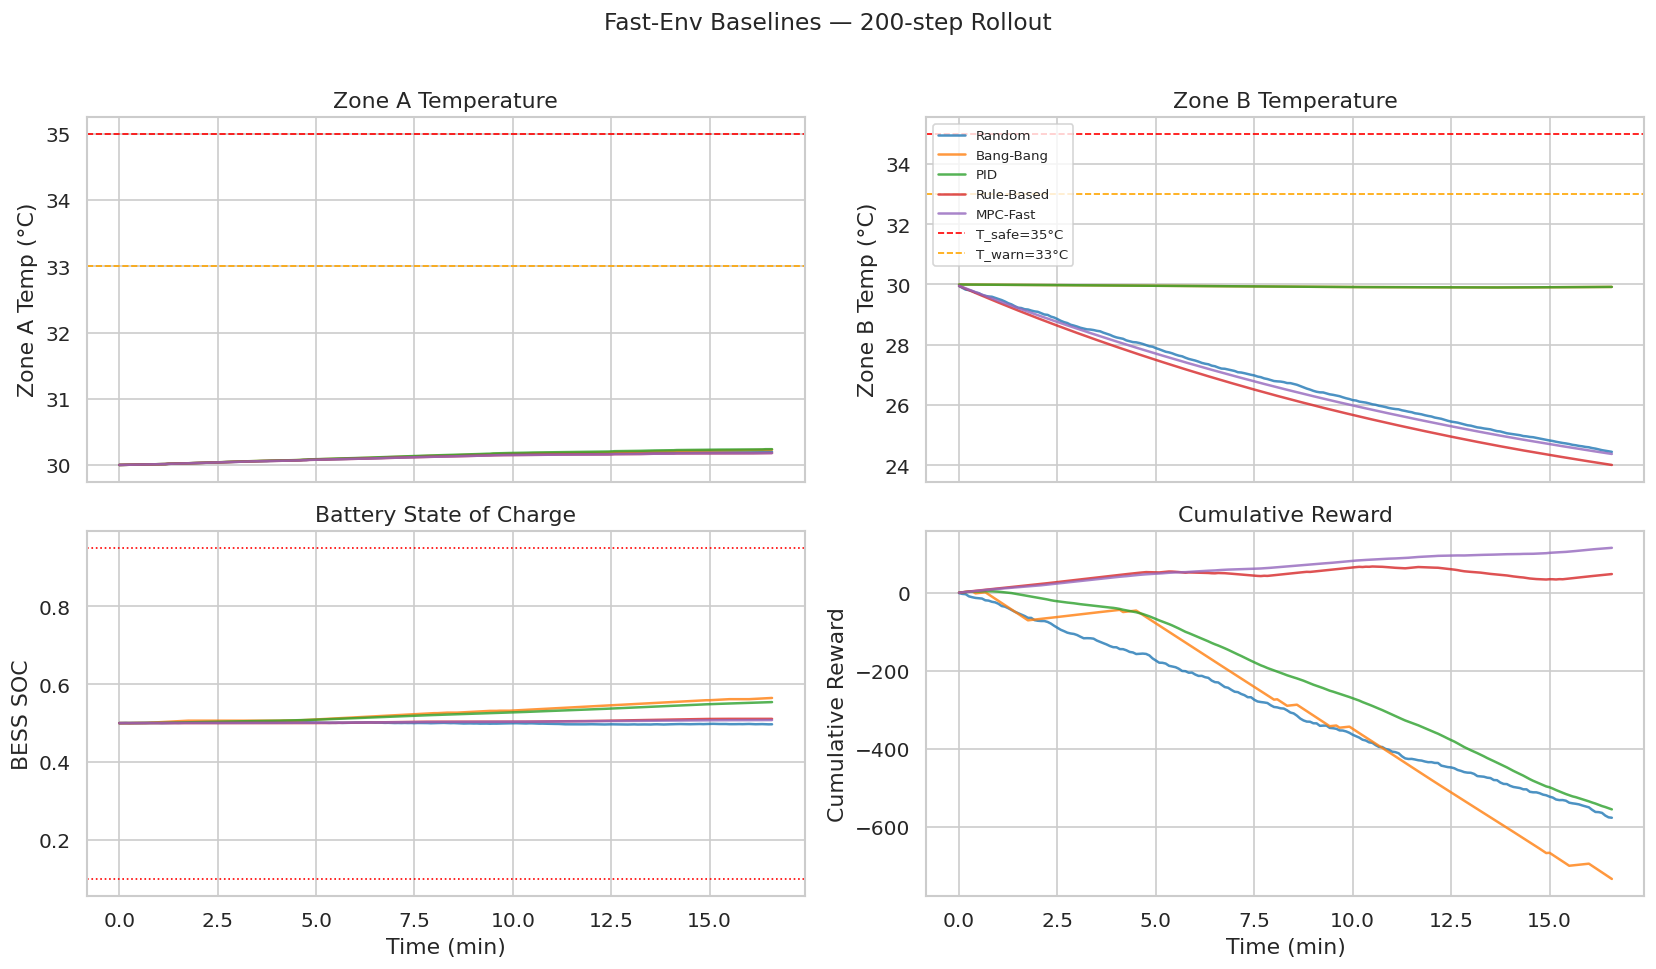

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
palette = sns.color_palette("tab10", len(fast_results))

for i, (name, df) in enumerate(fast_results.items()):
    c = palette[i]
    t = df["step"] * 5 / 60  # minutes

    # Temperature Zone A
    if "temp_A" in df.columns:
        axes[0, 0].plot(t, df["temp_A"], label=name, color=c, alpha=0.8)
    # Temperature Zone B
    if "temp_B" in df.columns:
        axes[0, 1].plot(t, df["temp_B"], label=name, color=c, alpha=0.8)
    # BESS SOC
    if "bess_soc" in df.columns:
        axes[1, 0].plot(t, df["bess_soc"], label=name, color=c, alpha=0.8)
    # Cumulative reward
    axes[1, 1].plot(t, df["reward"].cumsum(), label=name, color=c, alpha=0.8)

# Reference lines
for ax in [axes[0, 0], axes[0, 1]]:
    ax.axhline(35, color="red", ls="--", lw=1, label="T_safe=35°C")
    ax.axhline(33, color="orange", ls="--", lw=1, label="T_warn=33°C")
axes[1, 0].axhline(0.10, color="red", ls=":", lw=1, label="SOC_min")
axes[1, 0].axhline(0.95, color="red", ls=":", lw=1, label="SOC_max")

axes[0, 0].set_ylabel("Zone A Temp (°C)")
axes[0, 1].set_ylabel("Zone B Temp (°C)")
axes[1, 0].set_ylabel("BESS SOC")
axes[1, 1].set_ylabel("Cumulative Reward")
for ax in axes[1, :]:
    ax.set_xlabel("Time (min)")

axes[0, 0].set_title("Zone A Temperature")
axes[0, 1].set_title("Zone B Temperature")
axes[1, 0].set_title("Battery State of Charge")
axes[1, 1].set_title("Cumulative Reward")

axes[0, 1].legend(loc="upper left", fontsize=8)
fig.suptitle("Fast-Env Baselines — 200-step Rollout", fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

## 4. Fast-Env Action Distributions

Violin plots showing the distribution of each action dimension across the episode, per baseline. This reveals whether controllers are bang-bang (bimodal) vs smooth (PID/MPC).

/tmp/ipykernel_3145785/397912369.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=subset, x="Baseline", y="Value",
/tmp/ipykernel_3145785/397912369.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=subset, x="Baseline", y="Value",
/tmp/ipykernel_3145785/397912369.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=subset, x="Baseline", y="Value",
/tmp/ipykernel_3145785/397912369.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variab

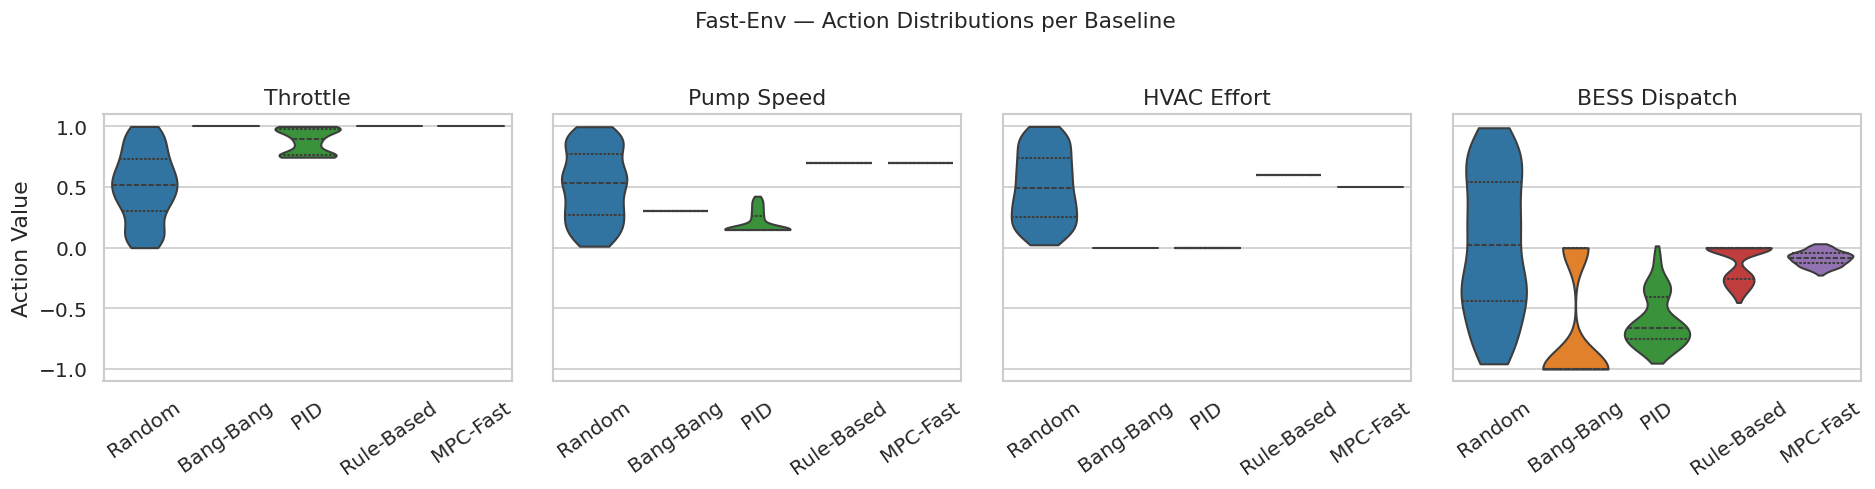

In [ ]:
action_labels = ["Throttle", "Pump Speed", "HVAC Effort", "BESS Dispatch"]
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)

# Build a long-form DataFrame for seaborn
rows = []
for name, df in fast_results.items():
    for j, label in enumerate(action_labels):
        col = f"action_{j}"
        if col in df.columns:
            for val in df[col]:
                rows.append({"Baseline": name, "Action": label, "Value": val})
action_df = pd.DataFrame(rows)

for j, label in enumerate(action_labels):
    subset = action_df[action_df["Action"] == label]
    sns.violinplot(data=subset, x="Baseline", y="Value", hue="Baseline",
                   ax=axes[j], inner="quartile", cut=0, palette="tab10", legend=False)
    axes[j].set_title(label)
    axes[j].set_xlabel("")
    axes[j].tick_params(axis="x", rotation=35)

axes[0].set_ylabel("Action Value")
fig.suptitle("Fast-Env — Action Distributions per Baseline", fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

## 5. Fast-Env Summary Metrics (Bar Chart)

Compare total reward, mean tracking error, max temperature, and mean SOC deviation from 50% across all fast-env baselines.

,Total Reward,Mean Reward/step,Episode Length,Max Temp A (°C),Max Temp B (°C),Mean |SOC - 0.5|,Mean Tracking Err (kW)
Baseline,,,,,,,
Random,-576.187,-2.881,200,30.201,29.949,0.002,25307.925
Bang-Bang,-733.108,-3.666,200,30.232,29.999,0.028,34914.445
PID,-554.733,-2.774,200,30.239,29.999,0.023,27400.198
Rule-Based,48.597,0.243,200,30.181,29.953,0.004,5677.606
MPC-Fast,115.860,0.579,200,30.181,29.957,0.003,3155.249


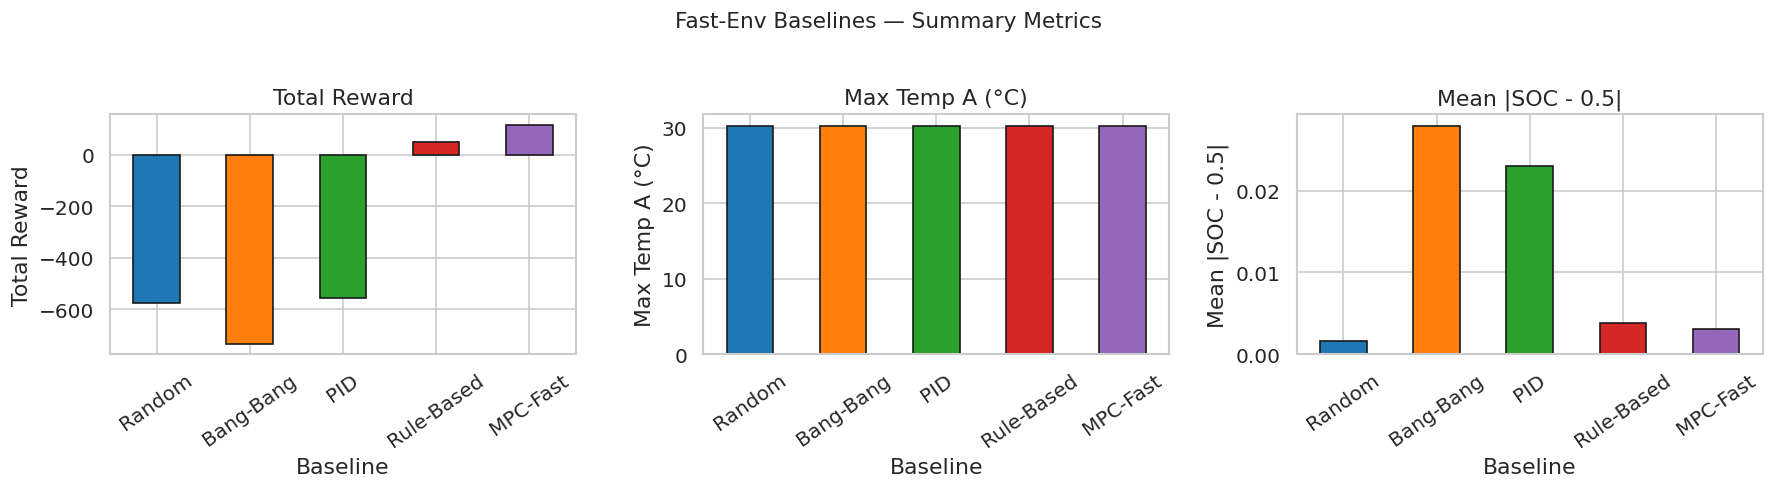

In [6]:
summary_rows = []
for name, df in fast_results.items():
    row = {"Baseline": name}
    row["Total Reward"] = df["reward"].sum()
    row["Mean Reward/step"] = df["reward"].mean()
    row["Episode Length"] = len(df)
    if "temp_A" in df.columns:
        row["Max Temp A (°C)"] = df["temp_A"].max()
    if "temp_B" in df.columns:
        row["Max Temp B (°C)"] = df["temp_B"].max()
    if "bess_soc" in df.columns:
        row["Mean |SOC - 0.5|"] = (df["bess_soc"] - 0.5).abs().mean()
    if "tracking_err_kw" in df.columns:
        row["Mean Tracking Err (kW)"] = df["tracking_err_kw"].abs().mean()
    summary_rows.append(row)

summary_fast = pd.DataFrame(summary_rows).set_index("Baseline")
display(summary_fast.round(3))

# Bar charts
metrics_to_plot = ["Total Reward", "Max Temp A (°C)", "Mean |SOC - 0.5|"]
available = [m for m in metrics_to_plot if m in summary_fast.columns]
fig, axes = plt.subplots(1, len(available), figsize=(5 * len(available), 4))
if len(available) == 1:
    axes = [axes]

for ax, metric in zip(axes, available):
    summary_fast[metric].plot.bar(ax=ax, color=palette[:len(fast_results)], edgecolor="k")
    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=35)

fig.suptitle("Fast-Env Baselines — Summary Metrics", fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

---
## 6. Macro-Env Rollouts (15-minute ticks)

Run each macro-env baseline for 48 steps (≈ 12 hours simulated time).

In [7]:
MACRO_STEPS = 48

env_macro = C2GMacroEnv()

macro_agents = {
    "Random":          RandomAgent(env_macro),
    "Rule-Based":      RuleBasedMacroController(),
    "MPC-Macro":       MPCMacroController(horizon=4),    # shorter for speed
    "MILP Dispatch":   MILPDispatchController(horizon=4),
}

macro_results = {}
for name, agent in macro_agents.items():
    print(f"Running {name}...", end=" ")
    df = rollout(env_macro, agent, n_steps=MACRO_STEPS)
    macro_results[name] = df
    print(f"done — {len(df)} steps, total reward = {df['reward'].sum():.2f}")

print("\nAll macro-env rollouts complete.")

Running Random... done — 48 steps, total reward = -357.33
Running Rule-Based... done — 48 steps, total reward = -53.15
Running MPC-Macro... done — 48 steps, total reward = 18.88
Running MILP Dispatch... done — 48 steps, total reward = 18.91

All macro-env rollouts complete.


## 7. Macro-Env Time-Series: SOC, Commitment, Reward

Track how each macro controller manages BESS state-of-charge and MW commitment over the 12-hour horizon.

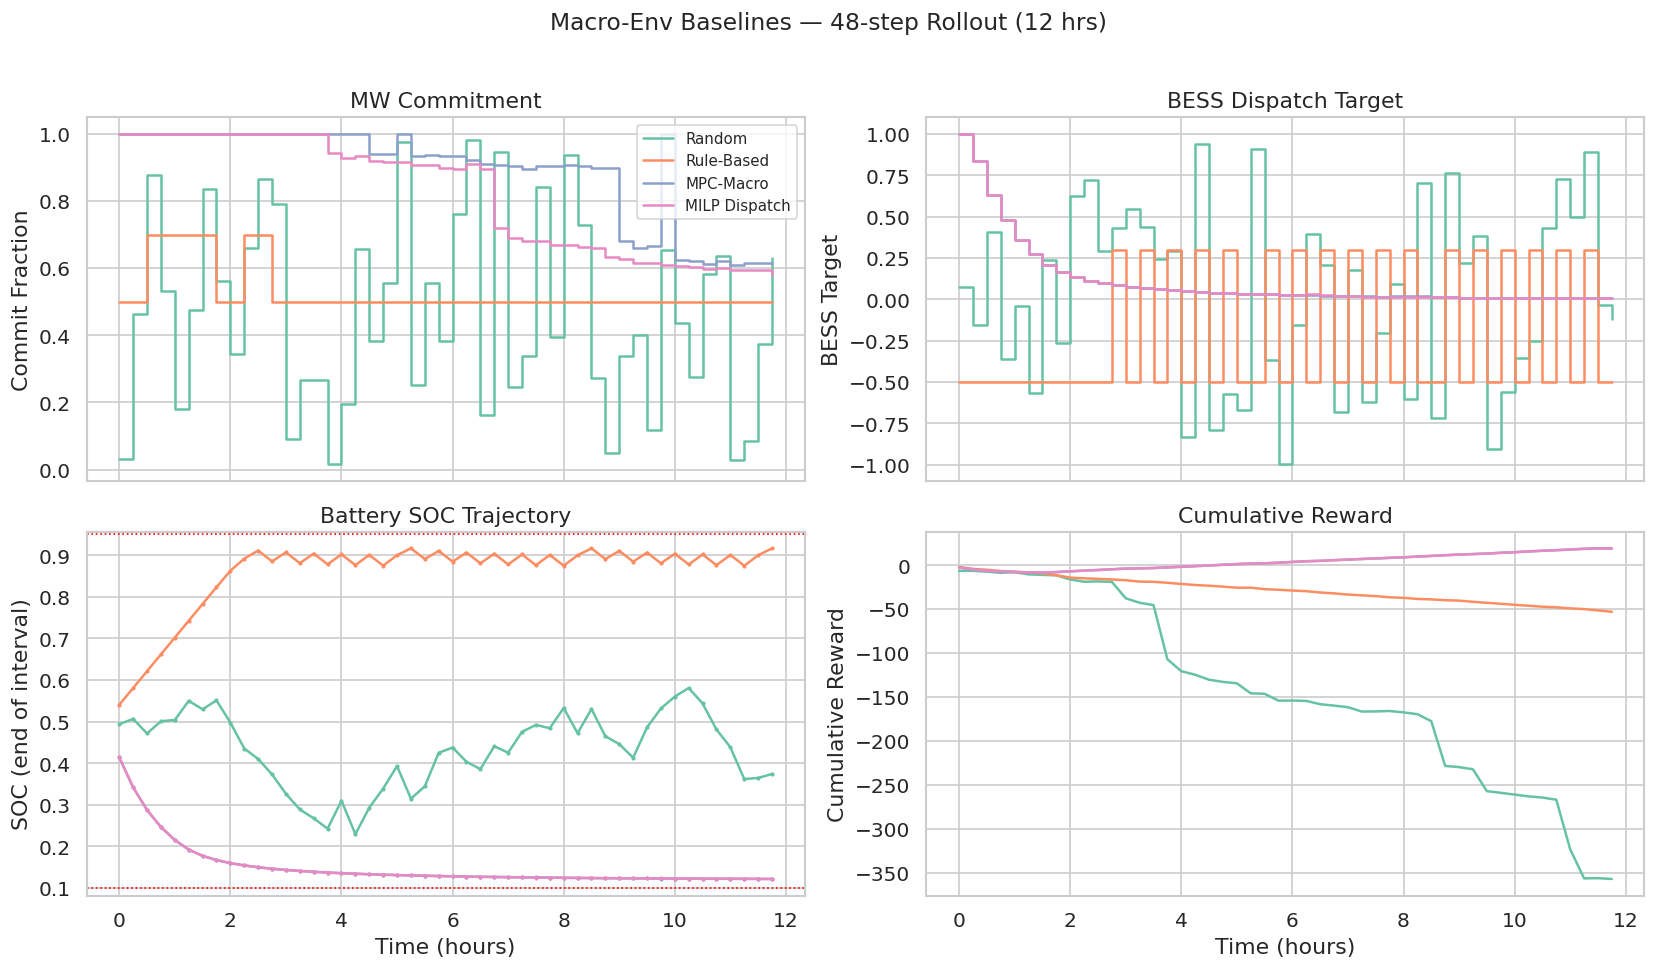

In [8]:
macro_palette = sns.color_palette("Set2", len(macro_results))
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)

for i, (name, df) in enumerate(macro_results.items()):
    c = macro_palette[i]
    t = df["step"] * 15 / 60  # hours

    # Commitment (action_0)
    if "action_0" in df.columns:
        axes[0, 0].step(t, df["action_0"], label=name, color=c, where="post")
    # BESS target (action_1)
    if "action_1" in df.columns:
        axes[0, 1].step(t, df["action_1"], label=name, color=c, where="post")
    # SOC end
    if "bess_soc_end" in df.columns:
        axes[1, 0].plot(t, df["bess_soc_end"], label=name, color=c, marker=".", ms=3)
    # Cumulative reward
    axes[1, 1].plot(t, df["reward"].cumsum(), label=name, color=c)

axes[1, 0].axhline(0.10, color="red", ls=":", lw=1)
axes[1, 0].axhline(0.95, color="red", ls=":", lw=1)

axes[0, 0].set_ylabel("Commit Fraction")
axes[0, 1].set_ylabel("BESS Target")
axes[1, 0].set_ylabel("SOC (end of interval)")
axes[1, 1].set_ylabel("Cumulative Reward")
for ax in axes[1, :]:
    ax.set_xlabel("Time (hours)")

axes[0, 0].set_title("MW Commitment")
axes[0, 1].set_title("BESS Dispatch Target")
axes[1, 0].set_title("Battery SOC Trajectory")
axes[1, 1].set_title("Cumulative Reward")

axes[0, 0].legend(fontsize=9)
fig.suptitle("Macro-Env Baselines — 48-step Rollout (12 hrs)", fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

## 8. Macro-Env Summary Table

In [9]:
summary_macro_rows = []
for name, df in macro_results.items():
    row = {"Baseline": name}
    row["Total Reward"] = df["reward"].sum()
    row["Mean Reward/step"] = df["reward"].mean()
    row["Episode Length"] = len(df)
    if "bess_soc_end" in df.columns:
        row["Final SOC"] = df["bess_soc_end"].iloc[-1]
        row["Mean |SOC - 0.5|"] = (df["bess_soc_end"] - 0.5).abs().mean()
    if "temp_A_max" in df.columns:
        row["Peak Temp A (°C)"] = df["temp_A_max"].max()
    if "committed_mw" in df.columns:
        row["Mean Commit (MW)"] = df["committed_mw"].mean()
    if "lmp_bonus" in df.columns:
        row["Total LMP Bonus"] = df["lmp_bonus"].sum()
    summary_macro_rows.append(row)

summary_macro = pd.DataFrame(summary_macro_rows).set_index("Baseline")
display(summary_macro.round(3))

,Total Reward,Mean Reward/step,Episode Length,Final SOC,Mean |SOC - 0.5|,Peak Temp A (°C),Mean Commit (MW),Total LMP Bonus
Baseline,,,,,,,,
Random,-357.334,-7.444,48,0.374,0.086,30.414,14.026,0.181
Rule-Based,-53.149,-1.107,48,0.916,0.358,30.414,15.875,0.084
MPC-Macro,18.884,0.393,48,0.122,0.349,30.414,26.568,0.064
MILP Dispatch,18.911,0.394,48,0.122,0.349,30.414,24.545,0.064


## 9. Statistical Comparison — Multi-Seed Evaluation

Run each fast-env baseline over 5 random seeds and compare mean total reward with 95% confidence intervals.

Multi-seed rollouts done.



,Mean Reward,Std,Min,Max
Random,-592.869,33.615,-625.607,-547.184
Bang-Bang,-848.355,105.411,-962.780,-694.355
PID,-645.402,107.621,-747.434,-497.587
Rule-Based,-66.465,81.886,-160.349,20.104
MPC-Fast,76.833,30.091,39.494,110.210


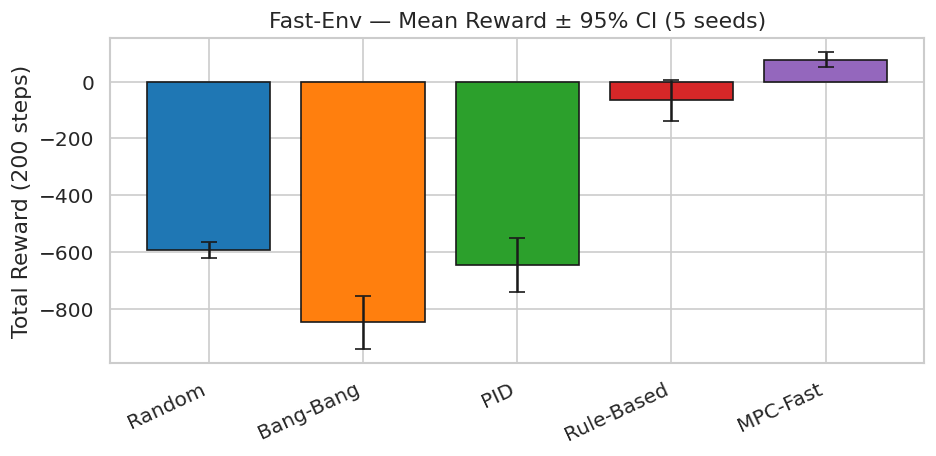

In [10]:
from scipy import stats

N_SEEDS = 5
EVAL_STEPS = 200
seeds = list(range(N_SEEDS))

seed_rewards = {name: [] for name in fast_agents}

for seed in seeds:
    for name, agent in fast_agents.items():
        df = rollout(env_fast, agent, n_steps=EVAL_STEPS, seed=seed)
        seed_rewards[name].append(df["reward"].sum())

print("Multi-seed rollouts done.\n")

# Summary table with mean ± std
seed_df = pd.DataFrame(seed_rewards)
stats_df = pd.DataFrame({
    "Mean Reward": seed_df.mean(),
    "Std": seed_df.std(),
    "Min": seed_df.min(),
    "Max": seed_df.max(),
}).round(3)
display(stats_df)

# Bar chart with error bars
fig, ax = plt.subplots(figsize=(8, 4))
means = seed_df.mean()
stds = seed_df.std()
ci95 = 1.96 * stds / np.sqrt(N_SEEDS)
x = range(len(means))
ax.bar(x, means, yerr=ci95, capsize=5, color=palette[:len(means)], edgecolor="k")
ax.set_xticks(x)
ax.set_xticklabels(means.index, rotation=25, ha="right")
ax.set_ylabel("Total Reward (200 steps)")
ax.set_title(f"Fast-Env — Mean Reward ± 95% CI ({N_SEEDS} seeds)")
fig.tight_layout()
plt.show()

## 10. Pairwise Statistical Significance (Welch's t-test)

Heatmap of p-values from pairwise Welch's t-tests on multi-seed total rewards. Green cells (p < 0.05) indicate statistically significant differences between baselines.

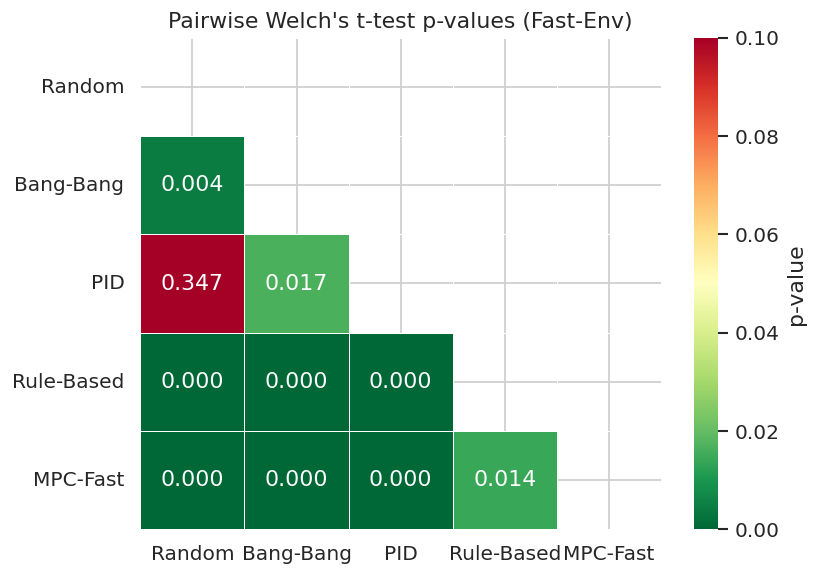

Pairs with p < 0.05:
  Random vs Bang-Bang: p = 0.0040
  Random vs Rule-Based: p = 0.0000
  Random vs MPC-Fast: p = 0.0000
  Bang-Bang vs PID: p = 0.0168
  Bang-Bang vs Rule-Based: p = 0.0000
  Bang-Bang vs MPC-Fast: p = 0.0000
  PID vs Rule-Based: p = 0.0000
  PID vs MPC-Fast: p = 0.0001
  Rule-Based vs MPC-Fast: p = 0.0141


In [11]:
names = list(seed_rewards.keys())
n = len(names)
pval_matrix = np.ones((n, n))

for i in range(n):
    for j in range(i + 1, n):
        _, p = stats.ttest_ind(seed_rewards[names[i]], seed_rewards[names[j]], equal_var=False)
        pval_matrix[i, j] = p
        pval_matrix[j, i] = p

pval_df = pd.DataFrame(pval_matrix, index=names, columns=names)

fig, ax = plt.subplots(figsize=(7, 5))
mask = np.triu(np.ones_like(pval_matrix, dtype=bool), k=0)
sns.heatmap(pval_df, annot=True, fmt=".3f", cmap="RdYlGn_r",
            mask=mask, vmin=0, vmax=0.1, ax=ax, linewidths=0.5,
            cbar_kws={"label": "p-value"})
ax.set_title("Pairwise Welch's t-test p-values (Fast-Env)")
fig.tight_layout()
plt.show()

print("Pairs with p < 0.05:")
for i in range(n):
    for j in range(i + 1, n):
        if pval_matrix[i, j] < 0.05:
            print(f"  {names[i]} vs {names[j]}: p = {pval_matrix[i,j]:.4f}")

## 11. Radar Chart — Multi-Dimensional Baseline Comparison

Normalised radar chart showing how each fast-env baseline performs across reward, thermal safety, SOC management, and tracking accuracy.

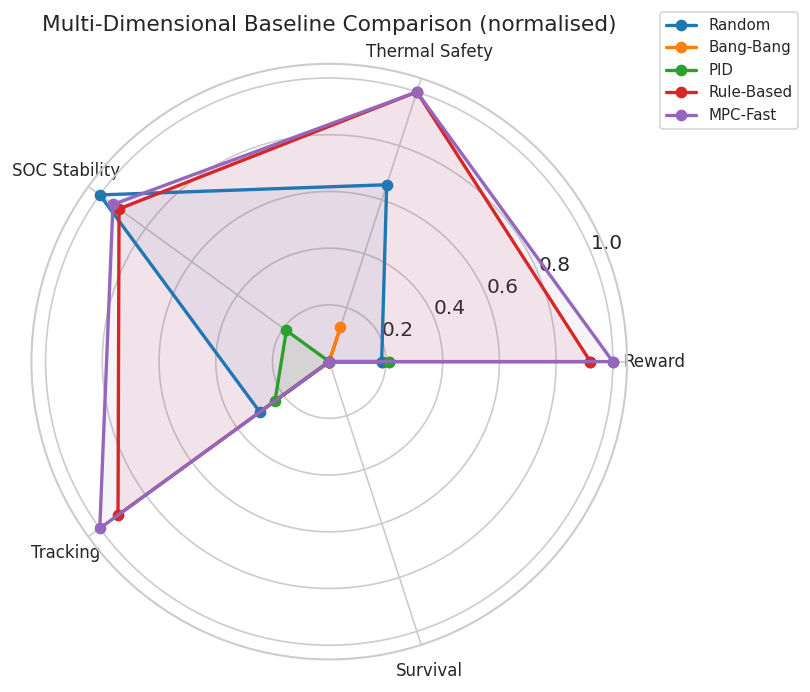

In [12]:
# Build radar metrics from single-seed run (seed=42)
radar_metrics = {}
for name, df in fast_results.items():
    m = {}
    m["Reward"] = df["reward"].sum()
    # Thermal safety: lower max temp is better → invert
    m["Thermal Safety"] = -(df["temp_A"].max() if "temp_A" in df.columns else 30)
    # SOC stability: lower deviation is better → invert
    m["SOC Stability"] = -(df["bess_soc"] - 0.5).abs().mean() if "bess_soc" in df.columns else 0
    # Tracking: lower error is better → invert
    m["Tracking"] = -df["tracking_err_kw"].abs().mean() if "tracking_err_kw" in df.columns else 0
    # Episode survival: longer is better
    m["Survival"] = len(df)
    radar_metrics[name] = m

radar_df = pd.DataFrame(radar_metrics).T
# Min-max normalise each column to [0, 1]
radar_norm = (radar_df - radar_df.min()) / (radar_df.max() - radar_df.min() + 1e-9)

# Draw radar
categories = list(radar_norm.columns)
N_cat = len(categories)
angles = np.linspace(0, 2 * np.pi, N_cat, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
for i, (name, row) in enumerate(radar_norm.iterrows()):
    values = row.tolist() + [row.tolist()[0]]
    ax.plot(angles, values, "o-", label=name, color=palette[i], lw=2)
    ax.fill(angles, values, alpha=0.08, color=palette[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=10)
ax.set_ylim(0, 1.05)
ax.set_title("Multi-Dimensional Baseline Comparison (normalised)", pad=20, fontsize=13)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=9)
fig.tight_layout()
plt.show()

## 12. Grid Signal Tracking Detail

Zoom into the BESS dispatch vs RegD signal to see how well each baseline tracks the grid regulation signal.

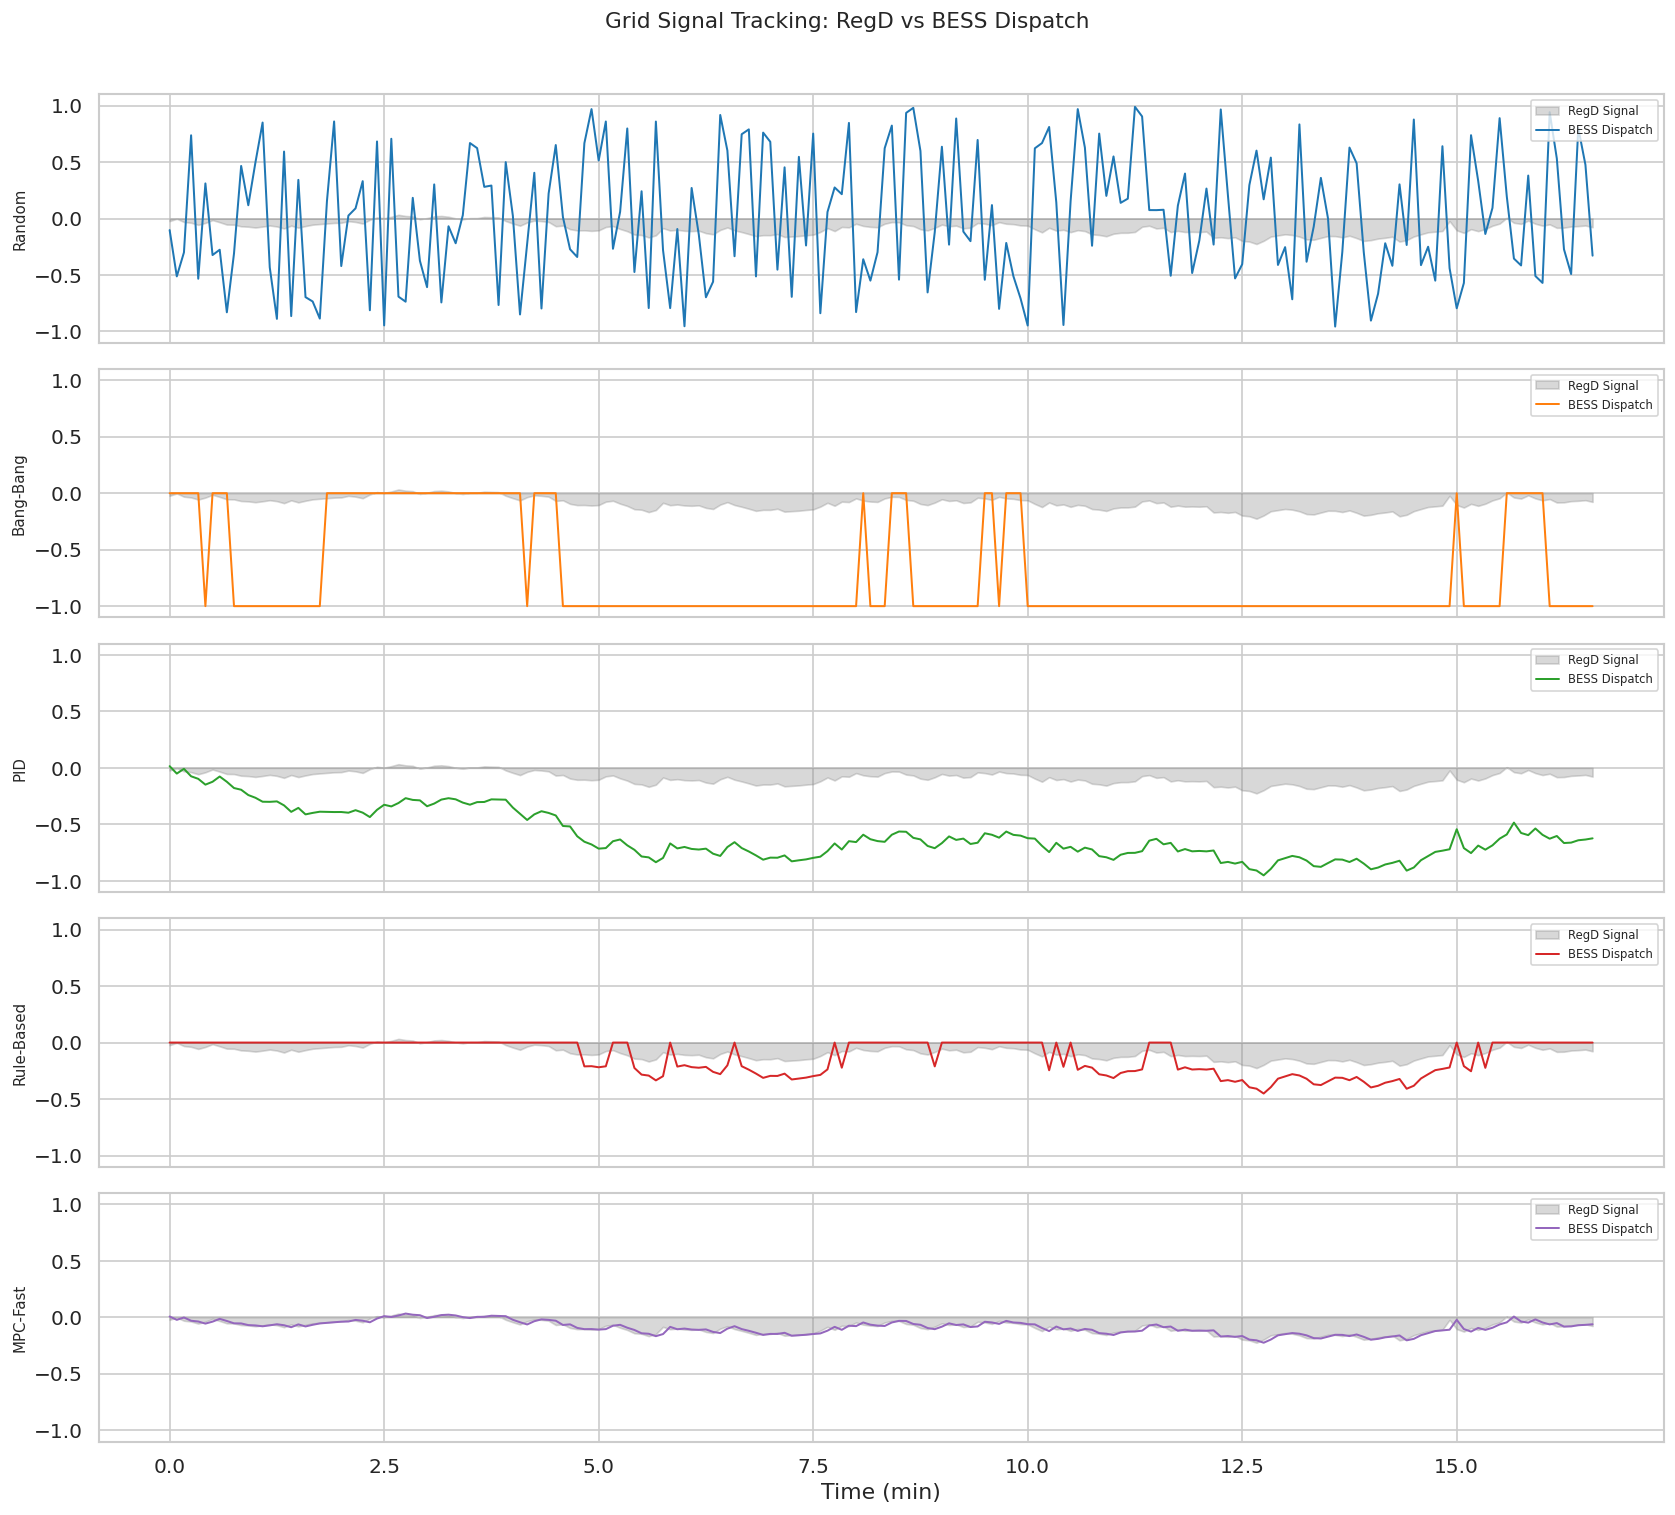

In [13]:
fig, axes = plt.subplots(len(fast_results), 1, figsize=(14, 2.5 * len(fast_results)),
                         sharex=True, sharey=True)

for i, (name, df) in enumerate(fast_results.items()):
    ax = axes[i]
    t = df["step"] * 5 / 60  # minutes
    if "regd_signal" in df.columns:
        ax.fill_between(t, df["regd_signal"], alpha=0.3, color="gray", label="RegD Signal")
    ax.plot(t, df["action_3"], color=palette[i], lw=1.2, label="BESS Dispatch")
    ax.set_ylabel(name, fontsize=9)
    ax.legend(loc="upper right", fontsize=7)
    ax.set_ylim(-1.1, 1.1)

axes[-1].set_xlabel("Time (min)")
fig.suptitle("Grid Signal Tracking: RegD vs BESS Dispatch", fontsize=13, y=1.01)
fig.tight_layout()
plt.show()